<a href="https://colab.research.google.com/github/muhamadr03/Praktikum-ML/blob/main/Praktikum%20Mandiri%2013/PraktikumMandiri13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle


In [ ]:
kaggle = '/content/kaggle.json'

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = "dataset"
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('Done')

Done


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# 1. KONFIGURASI & VARIABEL
dataset_path = '/content/dataset'
IMG_SIZE = 28
INPUT_DIM = IMG_SIZE * IMG_SIZE
X_raw = []
y_raw = []

print("--- 1. Memulai Proses Loading Data ---")

--- 1. Memulai Proses Loading Data ---


In [ ]:
# 2. LOAD DATASET & PREPROCESSING MANUAL
for label in range(10):
    folder_path = os.path.join(dataset_path, str(label))

    # Cek apakah folder ada
    if not os.path.exists(folder_path):
        continue

    files = os.listdir(folder_path)
    count = 0

    for file in files:
        try:
            img_path = os.path.join(folder_path, file)

            # A. Baca gambar (Grayscale)
            img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img_array is not None:
                # B. Invert Warna (Penting agar background hitam, angka putih)
                img_inverted = cv2.bitwise_not(img_array)

                # C. Resize ke 28x28
                img_resized = cv2.resize(img_inverted, (IMG_SIZE, IMG_SIZE))

                # D. Flattening (jadi 1 baris array)
                X_raw.append(img_resized.flatten())
                y_raw.append(label)
                count += 1

        except Exception as e:
            print(f"Error pada file {file}: {e}")

    print(f"   > Label {label}: {count} gambar berhasil di-load.")

# Konversi List ke Numpy Array
X = np.array(X_raw)
y = np.array(y_raw)

   > Label 0: 2236 gambar berhasil di-load.
   > Label 1: 2241 gambar berhasil di-load.
   > Label 2: 2233 gambar berhasil di-load.
   > Label 3: 2202 gambar berhasil di-load.
   > Label 4: 2179 gambar berhasil di-load.
   > Label 5: 2126 gambar berhasil di-load.
   > Label 6: 2121 gambar berhasil di-load.
   > Label 7: 2116 gambar berhasil di-load.
   > Label 8: 2085 gambar berhasil di-load.
   > Label 9: 2016 gambar berhasil di-load.


In [ ]:
# 3. NORMALISASI & SPLITTING
print("\n--- 2. Normalisasi & Splitting ---")

# Normalisasi pixel 0-255 menjadi 0-1
X = X.astype('float32') / 255.0

# One-Hot Encoding Label (misal angka 2 jadi [0,0,1,0...])
y_encoded = to_categorical(y, 10)

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"   > Data Training: {X_train.shape[0]}")
print(f"   > Data Testing : {X_test.shape[0]}")


--- 2. Normalisasi & Splitting ---
   > Data Training: 17244
   > Data Testing : 4311


In [ ]:
# 4. DEFINISI MODEL
# Menggunakan list constructor agar lebih rapi
model = Sequential([
    Input(shape=(INPUT_DIM,)),

    # Layer Hidden 1
    Dense(512, activation='relu', name='Layer_1'),
    Dropout(0.2),

    # Layer Hidden 2
    Dense(256, activation='relu', name='Layer_2'),
    Dropout(0.2),

    # Output Layer
    Dense(10, activation='softmax', name='Output_Layer')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


--- 3. Membangun Model ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Layer_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Layer_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 5. TRAINING
print("\n--- 4. Training Model ---")

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


--- 4. Training Model ---
Epoch 1/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.4287 - loss: 1.7101 - val_accuracy: 0.7333 - val_loss: 0.8684
Epoch 2/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7853 - loss: 0.7076 - val_accuracy: 0.8176 - val_loss: 0.5714
Epoch 3/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8765 - loss: 0.4108 - val_accuracy: 0.8655 - val_loss: 0.4297
Epoch 4/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9220 - loss: 0.2524 - val_accuracy: 0.8747 - val_loss: 0.4069
Epoch 5/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9419 - loss: 0.1898 - val_accuracy: 0.8721 - val_loss: 0.4139
Epoch 6/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9531 - loss: 0.1510 - val_accuracy: 0.8933 - val_loss: 0.3730
Epoch 7/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9613 - loss: 0.1240 - val_accuracy: 0.8907 - val_loss: 0.3841
Epoch 8/100
432/432 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accura


--- 5. Evaluasi & Grafik ---
Final Test Accuracy: 89.45%
Final Test Loss: 0.3642


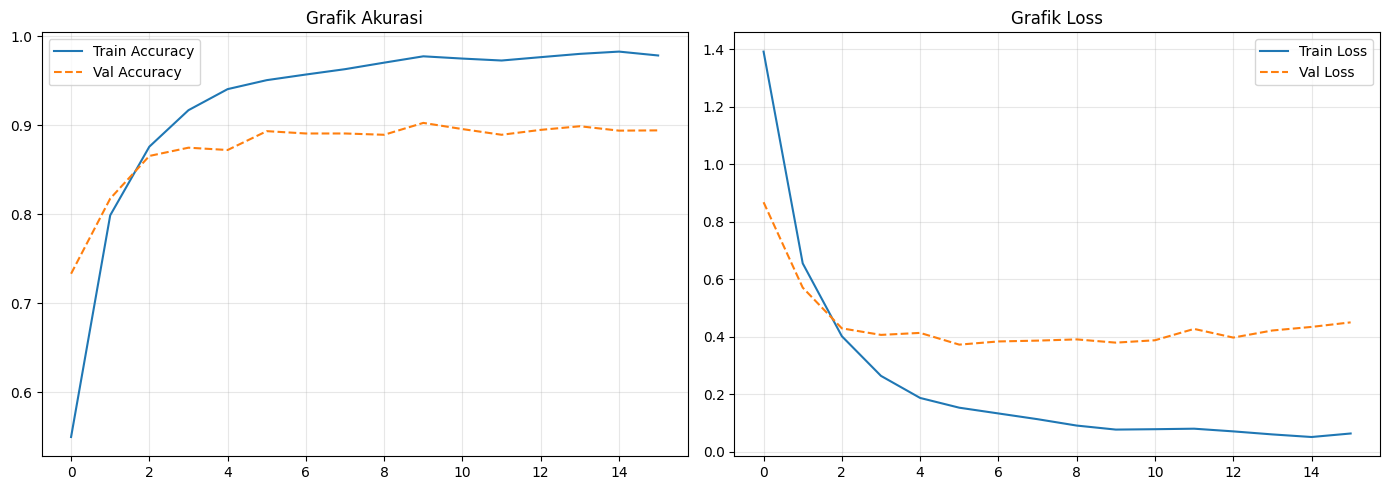

In [ ]:
# 6. EVALUASI & PLOT GRAFIK
print("\n--- 5. Evaluasi & Grafik ---")
# Evaluasi Score
loss_val, acc_val = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {acc_val*100:.2f}%")
print(f"Final Test Loss: {loss_val:.4f}")
# Plot Grafik Accuracy & Loss
plt.figure(figsize=(14, 5))
# Subplot 1: Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', linestyle='--')
plt.title('Grafik Akurasi')
plt.legend()
plt.grid(True, alpha=0.3)
# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss', linestyle='--')
plt.title('Grafik Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


--- 6. Confusion Matrix & Report ---
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


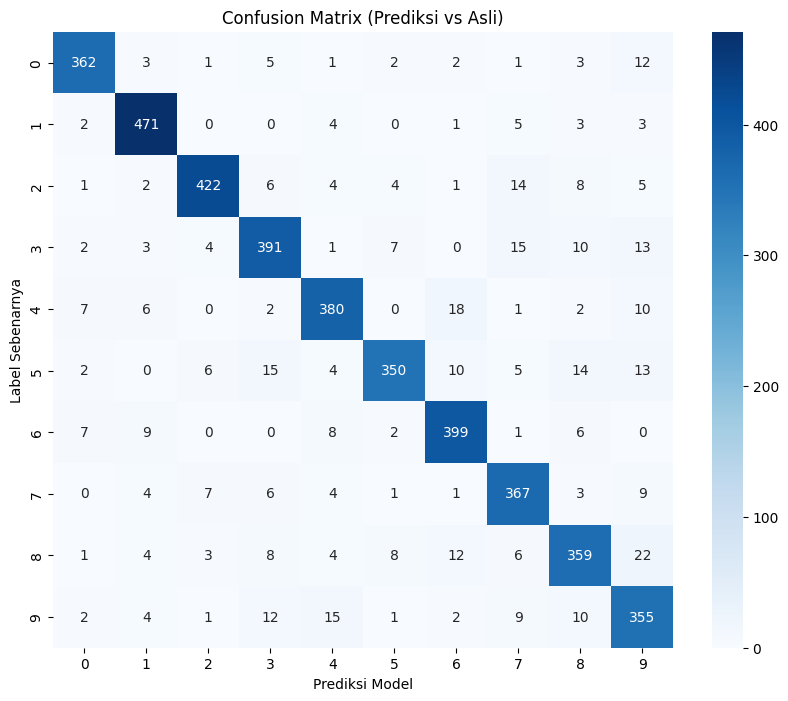


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       392
           1       0.93      0.96      0.95       489
           2       0.95      0.90      0.93       467
           3       0.88      0.88      0.88       446
           4       0.89      0.89      0.89       426
           5       0.93      0.84      0.88       419
           6       0.89      0.92      0.91       432
           7       0.87      0.91      0.89       402
           8       0.86      0.84      0.85       427
           9       0.80      0.86      0.83       411

    accuracy                           0.89      4311
   macro avg       0.89      0.89      0.89      4311
weighted avg       0.90      0.89      0.89      4311



In [ ]:
# 7. CONFUSION MATRIX & LAPORAN KLASIFIKASI
print("\n--- 6. Confusion Matrix & Report ---")

# Prediksi seluruh data test
y_pred_probs = model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1) # Hasil prediksi (0-9)
y_true_classes = np.argmax(y_test, axis=1)       # Label asli (0-9)

# Membuat Matriks Kebingungan (Confusion Matrix)
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Visualisasi Heatmap Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(10)],
            yticklabels=[str(i) for i in range(10)])
plt.title('Confusion Matrix (Prediksi vs Asli)')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Sebenarnya')
plt.show()

# Menampilkan Laporan Statistik Lengkap
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes))